# Flow Matching

Flow matching (or Conditional Flow Matching (CFM) ) is simple.

**Goal**: sample from a data distribution $p_1(x)$ which is known from examples $x_i$.

**Idea**: start from a distribution $p_0(x)$ one can sample an $x_0$ from  (as usual $\mathcal{N}(\mathbf{0}, \mathbf{I})$) and transform samples to points $x_1$ that are distributed according to $p_1$.

**Transformation**: A deterministic (!) path from $x_0$ to $x_1$ will be followed in the form of the solution to an ordinary differential equation:

$$\frac{d\mathbf{x}}{dt} = v_\theta(\mathbf{x}, t), \qquad \mathbf{x}(0) \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{x}(1) \sim p_\text{data},\quad t \in [0, 1]$$

$v_\theta$ is a parametrized vector field of the dimension of $x$ for all t and x. Think of data particles flow through time, and density of particles as probability density at each point in time.

**Role of the model**: optimize parameters $\theta$ to predict $v_\theta(\mathbf{x}, t)$. From that, the ODE can be solved, for example with the Euler method.


The key trick: **condition on individual data points**. For a pair $(\mathbf{x}_0, \mathbf{x}_1)$ define a **straight-line path**:

$$\mathbf{x}_t = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

Fit a model to predict a 'conditional vector field' along this path that is constant:

$$u_t(\mathbf{x} \mid \mathbf{x}_1) = \mathbf{x}_1 - \mathbf{x}_0$$

The model learns the flow from conditional paths (therefore conditional flow matching)

## Why does this work?
In general, we want to find a solution for $v$ that transforms the probability densities into each other. The continuity equation relating the flow of individual data particles and the probability densities is $$\frac{\partial p(\mathbf{x}, t)}{\partial t} + \nabla \cdot \bigl( p(\mathbf{x}, t)\, v(\mathbf{x}, t) \bigr) = 0$$

Each individual path $(x_0, x_1)$ is a straight line with constant velocity $\mathbf{x}_1 - \mathbf{x}_0$.
But many such lines from different pairs pass through the same point $\mathbf{x}_t$ in space-time - so the individual paths used during training are not the correct solution for our vector field for this equation (which must map a certain point to a single target via a deterministic trajectory).

**The mathematical foundation that was skipped here**:  CFM can be shown to recover a correct marginal velocity field (which does depend on time, and is therefor curved) **in expectation** across all random pairings.

In practice, the curvature is mild enough that 10–50 time steps are enough to solve the ODE.

(Note there is not single solution for v(t) given the distributions $p_0, p_1$, so the result the network learns depends on the sampling of training paths. With better sampling ("Optimal Transport"), straighter paths can be achieved, which need fewer steps for integration)

## Training

**Input**: Sample an $x_0$ from $\mathcal{N}(\mathbf{0}, \mathbf{I})$, pick a random $x_1$ from the data and $t \in (0, 1)$ to get an $\mathbf{x}_t = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$.


Target: the flow vector along the straight line path: $x_1 - x_0$

Objective: MSE between prediction and target: $$\mathcal{L}_\text{CFM} = \mathbb{E}_{\{(x_0, x_1)\}}\!\left[\left\|v_\theta\!\left(x_t; t\right) - (x_1 - x_0)\right\|^2\right]$$


## Sampling
- Sample a point $x_0$ from a normal distribution.
- Transform to $x_1$ by solving the ODE with the derivative vector field from the model. For example using the Euler method:

  $x(t+\Delta) = x(t) + \Delta \cdot v(x(t), t)$
  starting from $x(t=0) = x_0$, or any other ODE solver.

## Context and References

### Not to be confused with normalizing flows

Classical normalizing flows learn a single *static* invertible function $F_\theta: \mathcal{N}(\mathbf{0},\mathbf{I}) \to p_\text{data}$ and train it by maximising exact log-likelihood via the change-of-variables formula. This requires architecturally constrained invertible networks (coupling layers, autoregressive flows) and a tractable Jacobian determinant — limiting expressivity.

Flow matching instead learns a *time-dependent velocity field* and trains it by simple MSE regression. The architecture is unconstrained, and no Jacobian is needed during training.

### References

- **Lipman et al. (2023)** — [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) (ICLR). Introduced the CFM objective and the conditional-path trick.
- **Liu et al. (2023)** — [Rectified Flow](https://arxiv.org/abs/2209.03003) (ICLR). Concurrent work emphasizing straight paths and iterative "reflow" to straighten trajectories.
- **Albergo & Vanden-Eijnden (2023)** — [Stochastic Interpolants](https://arxiv.org/abs/2209.15571) (ICLR). Concurrent, more general framework interpolating between arbitrary distributions.

### Relation to diffusion and stochastic path models

Diffusion models (score matching / DDPM) can be recast as flow matching with a specific, curved probability path — the one induced by Gaussian noising. Flow matching generalizes this: *any* interpolation between $p_0$ and $p_1$ is allowed, and straight paths are a particularly convenient choice that diffusion does not give you.

- **Tong et al. (2023)** — [Improving and Generalizing Flow-Based Generative Models](https://arxiv.org/abs/2302.00482). Makes the connection to diffusion and optimal transport explicit; introduces OT-CFM using minibatch OT couplings for straighter paths.
- **Song et al. (2021)** — [Score-Based Generative Modeling through SDEs](https://arxiv.org/abs/2011.13456). The probability-flow ODE view of diffusion, which is the bridge to flow matching.


In [1]:
import jax
import jax.numpy as jnp
from jax import random, jit, vmap
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt

# silence some warnings
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

key = random.PRNGKey(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print('JAX:', jax.__version__, '| devices:', jax.devices())

JAX: 0.9.2 | devices: [CudaDevice(id=0)]


## Toy Data Set

A simple but not trivial dataset: can be visualized in 2d, concentrates data on a low dimensional manifold, and is clustered.

In [2]:
def sample_data(key, n=2000, sigma_z=0.3, sigma_obs=0.05):
    """Sample n points from the circular two-cluster dataset.

    Latent z ~ equal mixture of N(pi/2, sigma_z) and N(3pi/2, sigma_z), wrapped to [0, 2pi].
    Observed x = (cos z, sin z) + N(0, sigma_obs^2 I).

    Returns:
        x: (n, 2) observed positions
        z: (n,) true latent angles in [0, 2pi]
    """
    k1, k2, k3 = random.split(key, 3)
    components = random.bernoulli(k1, p=0.5, shape=(n,))
    centers = jnp.where(components, 3 * jnp.pi / 2, jnp.pi / 2)
    z_raw = centers + sigma_z * random.normal(k2, shape=(n,))
    z = z_raw % (2 * jnp.pi)
    x_clean = jnp.stack([jnp.cos(z), jnp.sin(z)], axis=-1)
    x = x_clean + sigma_obs * random.normal(k3, shape=(n, 2))
    return x, z

key = random.PRNGKey(0)
sigma_z = 0.3
x_data, _ = sample_data(key, sigma_z=sigma_z)
num_samples, num_d = x_data.shape
print(f"x shape: {x_data.shape}")


x shape: (2000, 2)


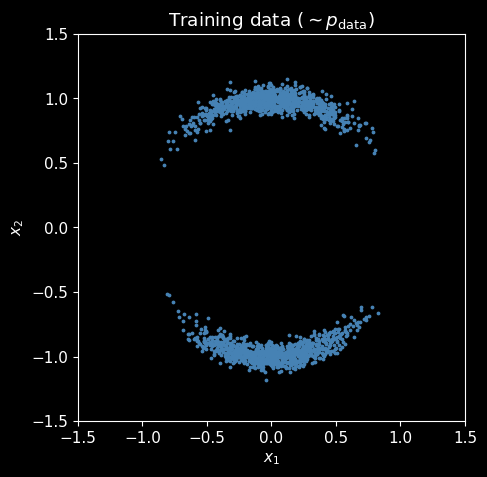

In [3]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.scatter(x_data[:, 0], x_data[:, 1], s=3, c='steelblue')
ax.set_title('Training data ($ \\sim p_{\\text{data}}$)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Interpolation via Straight-Line Paths

For each pair $(\mathbf{x}_0, \mathbf{x}_1)$ — a noise sample and a data sample — define the **linear interpolation**:

$$\mathbf{x}_t = (1 - t)\,\mathbf{x}_0 + t\,\mathbf{x}_1, \qquad t \in [0, 1]$$

- At $t=0$: $\mathbf{x}_t = \mathbf{x}_0$ — pure noise.
- At $t=1$: $\mathbf{x}_t = \mathbf{x}_1$ — real data.
- In between: a straight-line mixture.

The target velocity along this path is constant:

$$u_t(\mathbf{x} \mid \mathbf{x}_1) = \frac{d\mathbf{x}_t}{dt} = \mathbf{x}_1 - \mathbf{x}_0$$

Below we visualise the distribution $p_t$ at five values of $t$, together with a few individual straight-line paths.

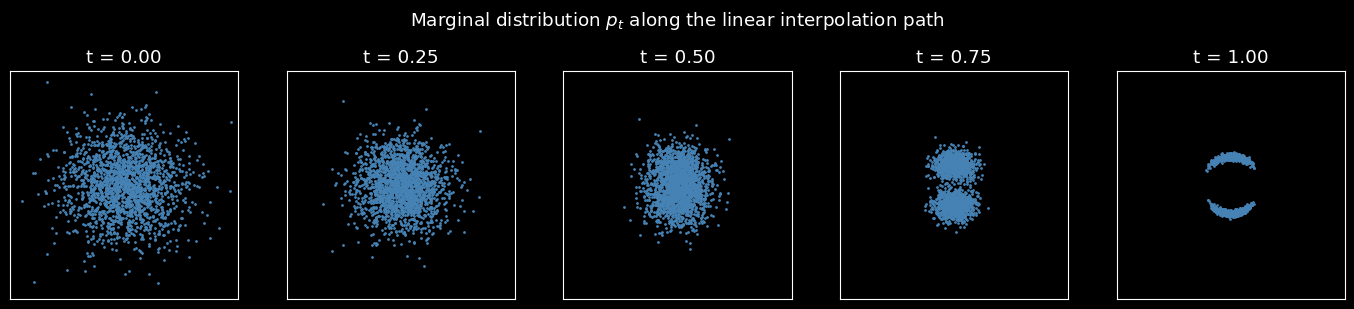

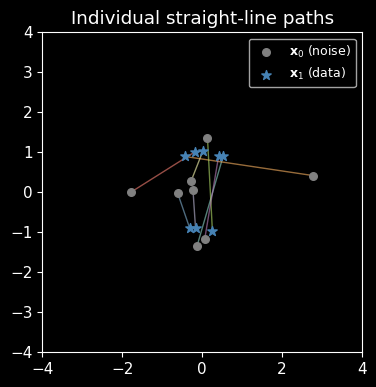

In [4]:
def interpolate(x0, x1, t):
    """Linear path: x_t = (1-t)*x0 + t*x1."""
    return (1 - t) * x0 + t * x1

key, sk1, sk2 = random.split(key, 3)
x0_pool = random.normal(sk1, x_data.shape)   # noise samples (x0)
x1_pool = x_data.copy()

# --- Marginal distributions at different t ---
show_t = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, t_val in zip(axes, show_t):
    xt = interpolate(x0_pool, x1_pool, t_val)
    ax.scatter(np.array(xt[:, 0]), np.array(xt[:, 1]), s=1, c='steelblue')
    ax.set_title(f't = {t_val:.2f}')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Marginal distribution $p_t$ along the linear interpolation path', y=1.02)
plt.tight_layout(); plt.show()

# --- Individual straight-line paths ---
n_paths = 8
key, sk1 = random.split(key)
inds = random.randint(sk1, (n_paths,), 0, num_samples)
fig, ax = plt.subplots(figsize=(5, 4))
for ind in inds:
    ax.plot([x0_pool[ind, 0], x1_pool[ind, 0]], [x0_pool[ind, 1], x1_pool[ind, 1]], lw=1, alpha=0.6)
    ax.scatter(*x0_pool[ind], c='grey',      s=30, zorder=3)
    ax.scatter(*x1_pool[ind], c='steelblue', s=50, marker='*', zorder=3)
ax.scatter([], [], c='grey',      s=30, label='$\\mathbf{x}_0$ (noise)')
ax.scatter([], [], c='steelblue', s=50, marker='*', label='$\\mathbf{x}_1$ (data)')
ax.set_title('Individual straight-line paths'); ax.legend(fontsize=9)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Training

For one training step:

1. Sample $\mathbf{x}_1 \sim p_{\text{data}}$ (a real data point)
2. Sample $\mathbf{x}_0 \sim \mathcal{N}(\mathbf{0},\mathbf{I})$ (fresh noise — not stored)
3. Sample $t \sim \text{Uniform}(0, 1)$
4. Construct $\mathbf{x}_t = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$
5. **Input to network:** $(\mathbf{x}_t,\; t)$
6. **Target:** $\mathbf{x}_1 - \mathbf{x}_0$ (the constant straight-line direction)
7. **Loss:** $\|v_\theta(\mathbf{x}_t, t) - (\mathbf{x}_1 - \mathbf{x}_0)\|^2$

The network does *not* see: $\mathbf{x}_0$ or $\mathbf{x}_1$ directly — only the interpolated point $\mathbf{x}_t$. From $x_t$ and $t$, it must predict the difference vector $x_1-x_0$ - a hard and ambiguous (at the sample level) task.

Below a visualization of the task: given a red dot, predict the green arrow.

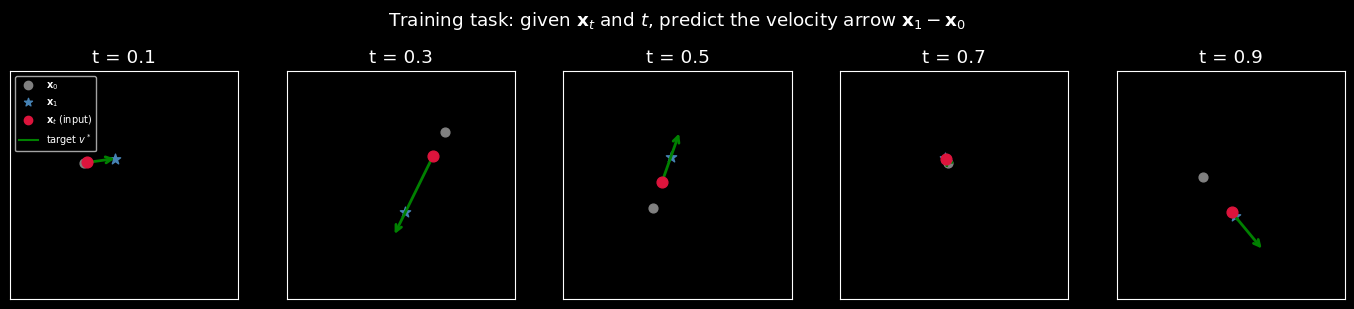

In [5]:
key, sk1, sk2 = random.split(key, 3)

num_plots = 5

x0_show = random.normal(sk1, (num_plots, 2))
inds = random.randint(sk1, (num_plots,), 0, num_samples)
x1_show = x_data[inds, :]
t_show  = jnp.array([0.1, 0.3, 0.5, 0.7, 0.9])

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, ax in enumerate(axes):
    t_val  = float(t_show[i])
    xt_i   = np.array(interpolate(x0_show[i], x1_show[i], t_val))
    v_star = np.array(x1_show[i] - x0_show[i])   # target velocity

    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect('equal')
    ax.scatter(*x0_show[i], c='grey',      s=40, zorder=3)
    ax.scatter(*x1_show[i], c='steelblue', s=60, marker='*', zorder=3)
    ax.scatter(*xt_i,        c='crimson',   s=60, zorder=4)
    ax.annotate('', xy=xt_i + v_star,
                xytext=xt_i,
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.scatter([], [], c='grey',      marker='o', label='$\\mathbf{x}_0$')
        ax.scatter([], [], c='steelblue', marker='*', label='$\\mathbf{x}_1$')
        ax.scatter([], [], c='crimson',   marker='o', label='$\\mathbf{x}_t$ (input)')
        ax.plot   ([], [], c='green',                 label='target $v^*$')
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Training task: given $\\mathbf{x}_t$ and $t$, predict the velocity arrow $\\mathbf{x}_1 - \\mathbf{x}_0$', y=1.02)
plt.tight_layout(); plt.show()

## Model Implementation for Velocity Prediction


- **Input:** $(\mathbf{x}_t, t) \in \mathbb{R}^2 \times [0,1]$
- **Time encoding:** sinusoidal embedding (same as Transformer positional encodings)
- **Body:** small MLP
- **Output:** $v_\theta(\mathbf{x}_t, t) \in \mathbb{R}^2$ — predicted velocity


In [6]:
class TimeEmbed(nn.Module):
    """Sinusoidal time embedding + learned linear projection.
    Encode t as a vector with components given by sin(f * t), cos(f * t), for a fixed sample of frequencies.
    These (engineered) features provide information for fine differences between ts close to each other as well as courser differences,
    and more components for the network to learn from the important input t
    """
    dim: int = 32

    @nn.compact
    def __call__(self, t_float):
        half  = self.dim // 2
        freqs = jnp.exp(-jnp.arange(half) * jnp.log(10000.0) / (half - 1)) #log-spaced frequencies from 1 down to ~1/10000
        args  = t_float[:, None] * freqs[None, :]         # (batch, half)
        emb   = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
        return nn.Dense(self.dim)(emb) # learned projection


class VelocityNet(nn.Module):
    """Predict velocity v_theta(x_t, t): (batch,2) + (batch,) float -> (batch,2).
    Fully connected network + Time embedding.
    """
    hidden: int = 128

    @nn.compact
    def __call__(self, x, t):
        emb = TimeEmbed()(t)                             # (batch, 32)
        h   = jnp.concatenate([x, emb], axis=-1)         # (batch, 34)
        h   = nn.Dense(self.hidden)(h)
        h   = nn.silu(h)                                 # swish activation function
        h   = nn.Dense(self.hidden)(h)
        h   = nn.silu(h)
        return nn.Dense(2)(h)                            # predicted velocity


model = VelocityNet()
key, sk = random.split(key)
dummy_t = jnp.zeros((1,))                                # t is float in [0,1] for FM
params  = model.init(sk, jnp.zeros((1, 2)), dummy_t)
n_p = sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))
print(f'Network parameters: {n_p:,}')

Network parameters: 22,306


## Training

The CFM loss is just MSE:

$$\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t,(x_0, x_1)}\!\left[\left\|v_\theta\!\left(x_t ; t\right) - (\mathbf{x}_1 - \mathbf{x}_0)\right\|^2\right]$$

For each batch:
- Draw $\mathbf{x}_1$ from the dataset
- Draw $\mathbf{x}_0 \sim \mathcal{N}(\mathbf{0},\mathbf{I})$ fresh
- Draw $t \sim \text{Uniform}(0,1)$ per sample
- Interpolate to get $\mathbf{x}_t$
- Regress $v_\theta(\mathbf{x}_t, t)$ against $\mathbf{x}_1 - \mathbf{x}_0$

Epoch    0  loss = 1.4037
Epoch  500  loss = 1.0351
Epoch 1000  loss = 0.9732
Epoch 1500  loss = 0.8201
Epoch 2000  loss = 0.8758
Epoch 2500  loss = 0.9027
Epoch 3000  loss = 0.8649
Epoch 3500  loss = 0.8988
Epoch 4000  loss = 0.8149
Epoch 4500  loss = 0.8110
Epoch 5000  loss = 0.8197
Epoch 5500  loss = 0.8265
Epoch 6000  loss = 0.9103
Epoch 6500  loss = 0.7601
Epoch 7000  loss = 0.6840
Epoch 7500  loss = 0.6681
Epoch 8000  loss = 0.8259
Epoch 8500  loss = 0.8924
Epoch 9000  loss = 0.9342
Epoch 9500  loss = 0.8828


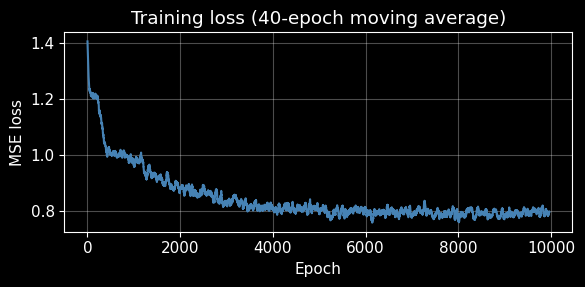

In [7]:
optimizer = optax.adam(3e-4)
opt_state = optimizer.init(params)


@jit
def train_step(params, opt_state, x1, key):
    k1, k2 = random.split(key)
    n      = x1.shape[0]
    x0     = random.normal(k1, x1.shape)               # fresh noise, not stored
    t      = random.uniform(k2, (n,))                  # t in [0,1], one per sample

    def loss_fn(params):
        xt     = (1 - t[:, None]) * x0 + t[:, None] * x1   # linear interpolation
        v_star = x1 - x0                                     # constant target velocity
        v_pred = model.apply(params, xt, t)
        return jnp.mean((v_pred - v_star) ** 2)

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state)
    return optax.apply_updates(params, updates), new_opt, loss


n_epochs, batch_size = 10000, 256
losses = []

for epoch in range(n_epochs):
    key, sk1, sk2 = random.split(key, 3)
    idx    = random.randint(sk1, (batch_size,), 0, len(x_data))
    batch  = x_data[idx]
    params, opt_state, loss_val = train_step(params, opt_state, batch, sk2)
    losses.append(float(loss_val))
    if epoch % 500 == 0:
        print(f'Epoch {epoch:4d}  loss = {loss_val:.4f}')

# Loss curve
w = 40
smoothed = np.convolve(losses, np.ones(w) / w, mode='valid')
plt.figure(figsize=(6, 3))
plt.plot(smoothed, lw=1.5, c='steelblue')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title(f'Training loss ({w}-epoch moving average)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Visualization of the Learned Velocity Field

Let's visualise $v_\theta(\mathbf{x}, t)$ at several values of $t$.

Each individual training path was a straight line. But because of the **marginal vs. conditional velocity** distinction: many straight conditional paths cross each point, and the network outputs their average, the resulting field induces curved trajectories.

First, a visualization of the learned field:

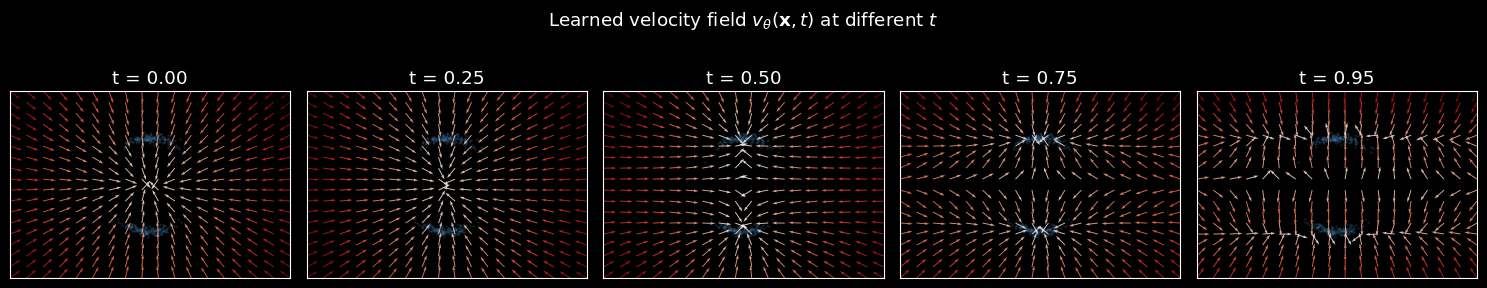

In [8]:
n_grid = 18
x_lim = (-3, 3)
y_lim = (-2, 2)
xs  = jnp.linspace(*x_lim, n_grid)
ys  = jnp.linspace(*y_lim, n_grid)
XX, YY = jnp.meshgrid(xs, ys)
grid   = jnp.stack([XX.ravel(), YY.ravel()], axis=-1)   # (n_grid^2, 2)

show_t = [0.0, 0.25, 0.5, 0.75, 0.95]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, t_val in zip(axes, show_t):
    t_batch = jnp.full((grid.shape[0],), t_val)
    vel     = np.array(model.apply(params, grid, t_batch))
    mag     = np.sqrt(vel[:, 0]**2 + vel[:, 1]**2) + 1e-8

    ax.scatter(np.array(x_data[:300, 0]), np.array(x_data[:300, 1]),
               s=1, alpha=0.15, c='steelblue')
    ax.quiver(np.array(grid[:, 0]), np.array(grid[:, 1]),
              vel[:, 0] / mag, vel[:, 1] / mag,
              mag, cmap='Reds', scale=22, alpha=0.85)
    ax.set_title(f't = {t_val:.2f}')
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Learned velocity field $v_\\theta(\\mathbf{x}, t)$ at different $t$', y=1.02)
plt.tight_layout(); plt.show()

## Sampling — Integrating the ODE Forward

Starting from $\mathbf{x}_0 \sim \mathcal{N}(\mathbf{0},\mathbf{I})$, integrate the learned ODE from $t=0$ to $t=1$ with the Euler Method (other solvers, like Runge-Kutta could be used to reduce the number of steps):

$$\mathbf{x}_{t + \Delta t} = \mathbf{x}_t + \Delta t \cdot v_\theta(\mathbf{x}_t, t)$$

In [9]:
def cfm_sample(params, n_samples, key, n_steps=50, save_every=10):
    """Euler integration of the learned ODE from t=0 to t=1."""
    key, sk   = random.split(key)
    x         = random.normal(sk, (n_samples, 2))   # start from noise
    dt        = 1.0 / n_steps
    trajectory = {0: np.array(x)}

    for step in range(n_steps):
        t_val   = step * dt
        t_batch = jnp.full((n_samples,), t_val)
        v       = model.apply(params, x, t_batch)   # predicted velocity
        x       = x + dt * v                        # Euler step
        if step % save_every == 0 or step == n_steps - 1:
            trajectory[step + 1] = np.array(x)

    return x, trajectory


print('Integrating ODE...')
key, sk = random.split(key)
samples, traj = cfm_sample(params, 2000, sk, n_steps=50)
print('Done.')

Integrating ODE...
Done.


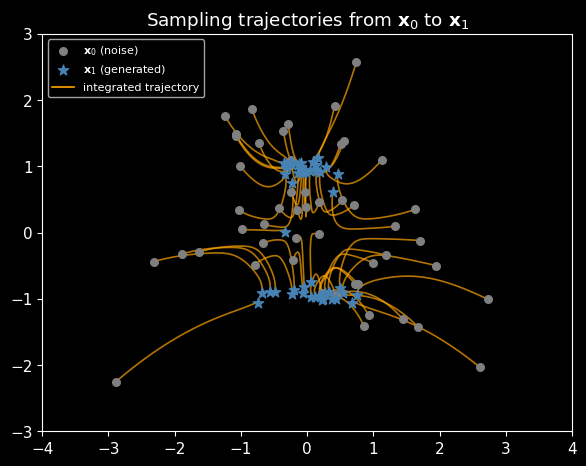

In [10]:
# --- A few integrated trajectories from x_0 (noise) to x_1 (data) ---
# Trajectories are curved even though training uses straight conditional paths.
n_traj  = 50
n_steps = 50
key, sk = random.split(key)
_, traj_full = cfm_sample(params, n_traj, sk, n_steps=n_steps, save_every=1)

# Stack the trajectory dict -> (n_steps+1, n_traj, 2)
steps_sorted = sorted(traj_full.keys())
paths = np.stack([traj_full[s] for s in steps_sorted], axis=0)

fig, ax = plt.subplots(figsize=(6, 5))

# Trajectory curves
for i in range(n_traj):
    ax.plot(paths[:, i, 0], paths[:, i, 1], lw=1.2, alpha=0.7, c='orange')

# Start (x_0, noise) and end (x_1, generated) markers
ax.scatter(paths[0, :, 0],  paths[0, :, 1],  c='grey',      s=30,             zorder=3)
ax.scatter(paths[-1, :, 0], paths[-1, :, 1], c='steelblue', s=60, marker='*', zorder=3)

# Legend proxies
ax.scatter([], [], c='grey',      s=30,             label='$\\mathbf{x}_0$ (noise)')
ax.scatter([], [], c='steelblue', s=60, marker='*', label='$\\mathbf{x}_1$ (generated)')
ax.plot   ([], [], c='orange',    lw=1.2,           label='integrated trajectory')
ax.legend(fontsize=8, loc='upper left')

ax.set_title('Sampling trajectories from $\\mathbf{x}_0$ to $\\mathbf{x}_1$')
ax.set_xlim(-4, 4); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

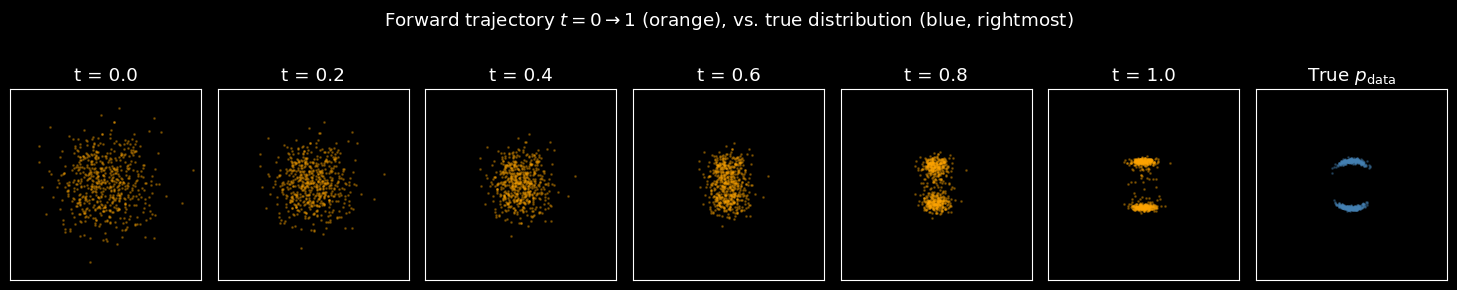

In [11]:
# --- Forward trajectory: noise -> data, with true distribution for comparison ---
# Re-sample with save_every=1 so we can pick exact t values for display.
n_samples = 2000
n_steps   = 50
key, sk   = random.split(key)
_, traj_all = cfm_sample(params, n_samples, sk, n_steps=n_steps, save_every=1)

show_t = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_panels = len(show_t) + 1                                   # + one panel for true data
fig, axes = plt.subplots(1, n_panels, figsize=(2.1 * n_panels, 3))

for ax, t_val in zip(axes[:-1], show_t):
    step = int(round(t_val * n_steps))
    pts  = traj_all[step][:600]
    ax.scatter(pts[:, 0], pts[:, 1], s=1, alpha=0.3, c='orange')
    ax.set_title(f't = {t_val:.1f}')

# Last panel: true data distribution (blue) for comparison
axes[-1].scatter(np.array(x_data[:600, 0]), np.array(x_data[:600, 1]),
                 s=1, alpha=0.3, c='steelblue')
axes[-1].set_title('True $p_{\\text{data}}$')

for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Forward trajectory $t = 0 \\to 1$ (orange), vs. true distribution (blue, rightmost)', y=1.02)
plt.tight_layout(); plt.show()

## Sampling Quality vs. Number of Steps

The number of steps in the ODE integration affects sampling quality - more steps are needed if the trajectories are curved.

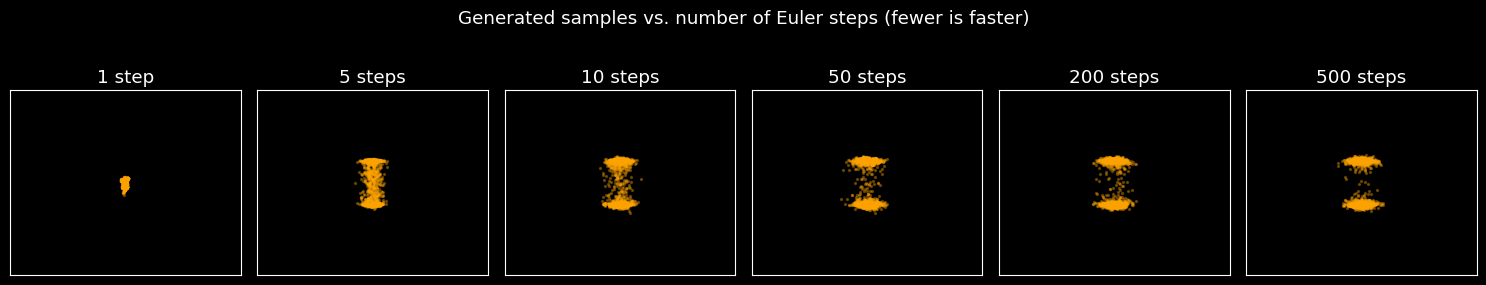

In [12]:
step_counts = [1, 5, 10, 50, 200, 500]
fig, axes = plt.subplots(1, len(step_counts), figsize=(15, 3))

for ax, n_steps in zip(axes, step_counts):
    key, sk = random.split(key)
    s, _    = cfm_sample(params, 1500, sk, n_steps=n_steps, save_every=9999)
    ax.scatter(np.array(s[:, 0]), np.array(s[:, 1]), s=2, alpha=0.3, c='orange')
    ax.set_title(f'{n_steps} step{"s" if n_steps > 1 else ""}')
    ax.set_xlim(-5, 5); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Generated samples vs. number of Euler steps (fewer is faster)', y=1.02)
plt.tight_layout(); plt.show()

## Visualizing Training with Conditional Paths: Marginal vs. Conditional Velocity

Each *conditional* path $(\mathbf{x}_0^{(i)}, \mathbf{x}_1^{(i)})$ is a straight line with constant velocity. But at any point $(\mathbf{x}_t, t)$ in space-time, **many different straight paths pass through**. The network outputs a single velocity there — the average over all such paths.

To visualize this: pick some straight paths that pass through a certain x at time t, as they would be used during training. Their expected average direction will be what the model learns.

(Note a subtle point: to make this work numerically, we should sample paths passing through x at t with the correct probability as they would appear during training, where pairs are picked randomly. Here we condition on $x_t$ and $x_1$, so the sample probabilities are not quite right).

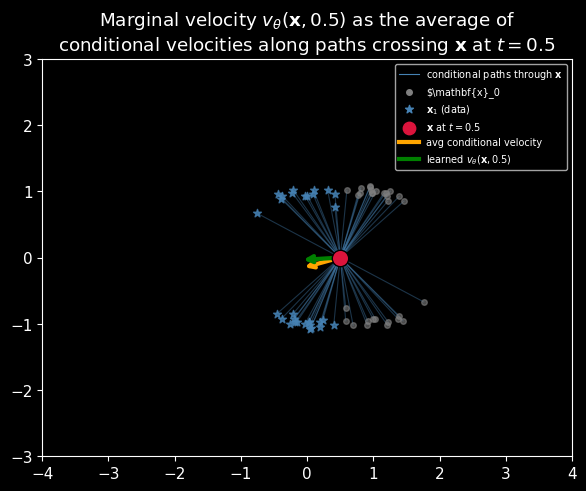

In [13]:

t_mid  = 0.5
x_pick = jnp.array([0.5, 0.0])                       # inspection point (on x-axis, symmetric between the two data blobs)

n_cond  = 30
key, sk = random.split(key)
inds    = random.randint(sk, (n_cond,), 0, num_samples)
x1_cond = x_data[inds]                               # (n, 2) data samples
x0_cond = 2 * x_pick[None, :] - x1_cond              # (n, 2) so midpoint == x_pick at t=0.5

v_cond    = x1_cond - x0_cond                        # (n, 2) conditional velocities
v_avg     = jnp.mean(v_cond, axis=0)                 # empirical average -> estimates the marginal
v_learned = np.array(
    model.apply(params, x_pick[None, :], jnp.array([t_mid]))
)[0]

fig, ax = plt.subplots(figsize=(6, 5))

# Conditional straight-line paths through x at t=0.5
for i in range(n_cond):
    ax.plot([x0_cond[i, 0], x1_cond[i, 0]],
            [x0_cond[i, 1], x1_cond[i, 1]],
            lw=0.8, alpha=0.4, c='steelblue')

# Endpoint markers
ax.scatter(np.array(x0_cond[:, 0]), np.array(x0_cond[:, 1]),
           c='grey',      s=16, alpha=0.6, zorder=3)
ax.scatter(np.array(x1_cond[:, 0]), np.array(x1_cond[:, 1]),
           c='steelblue', s=35, alpha=0.8, marker='*', zorder=3)

# Inspection point x
ax.scatter(*np.array(x_pick), c='crimson', s=140,
           edgecolors='black', linewidths=1, zorder=5)

# Arrow: average of conditional velocities at x (unit-length for visibility)
v_avg_hat = np.array(v_avg) / (np.linalg.norm(v_avg) + 1e-8)
ax.annotate('', xy=np.array(x_pick) + 0.6 * v_avg_hat, xytext=np.array(x_pick),
            arrowprops=dict(arrowstyle='->', color='orange', lw=3))

# Arrow: learned marginal velocity v_theta(x, 0.5)
v_learned_hat = v_learned / (np.linalg.norm(v_learned) + 1e-8)
ax.annotate('', xy=np.array(x_pick) + 0.6 * v_learned_hat, xytext=np.array(x_pick),
            arrowprops=dict(arrowstyle='->', color='green', lw=3))

# Legend proxies
ax.plot   ([], [], c='steelblue', lw=0.8,           label='conditional paths through $\\mathbf{x}$')
ax.scatter([], [], c='grey',      s=16,             label='$\\mathbf{x}_0')
ax.scatter([], [], c='steelblue', s=35, marker='*', label='$\\mathbf{x}_1$ (data)')
ax.scatter([], [], c='crimson',   s=80,             label='$\\mathbf{x}$ at $t=0.5$')
ax.plot   ([], [], c='orange',    lw=3,             label='avg conditional velocity')
ax.plot   ([], [], c='green',     lw=3,             label='learned $v_\\theta(\\mathbf{x}, 0.5)$')
ax.legend(fontsize=7, loc='upper right')

ax.set_title('Marginal velocity $v_\\theta(\\mathbf{x}, 0.5)$ as the average of\n'
             'conditional velocities along paths crossing $\\mathbf{x}$ at $t=0.5$')
ax.set_xlim(-4, 4); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Comparison Flow Matching vs. DDPM

| | **DDPM**                                                                                   | **Flow Matching (CFM)** |
|---|--------------------------------------------------------------------------------------------|---|
| **Network input (training)** | $\sqrt{\bar\alpha_t}\,\mathbf{x}_1 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\varepsilon}$, $t$ | $(1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$, $t$ |
| **Training target** | $\boldsymbol{\varepsilon}$ (noise added)                                                   | $\mathbf{x}_1 - \mathbf{x}_0$ (direction to data) |
| **Loss** | $\|\boldsymbol{\varepsilon} - \varepsilon_\theta\|^2$                                      | $\|(\mathbf{x}_1 - \mathbf{x}_0) - v_\theta\|^2$ |
| **Inference direction** | Backwards: $T \to 0$                                                                       | Forwards: $0 \to 1$ |
| **Inference step** | Stochastic + Noise schedule                                                    | $\mathbf{x} \leftarrow \mathbf{x} + \Delta t \cdot v_\theta$ |
| **Typical steps** | 100–1000                                                                                   | 10–50 |
| **Exact likelihood** | No (ELBO bound)                                                                            | Yes (via ODE) |

The architectures for the model are in principle interchangeable — only the interpolation formula and prediction target change.

### Extensions to Explore

- **Flow matching at scale.** Stable Diffusion 3 and Flux (2024) apply flow matching in a compressed VAE latent space with a DiT-style transformer backbone. See Esser et al., [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206); Flux.1 (Black Forest Labs, 2024) builds on the same recipe.
- **Few-step / distilled models.** Trajectories from a trained flow can be distilled into a student that takes 1–4 steps. See [InstaFlow](https://arxiv.org/abs/2309.06380) and the reflow procedure from the Rectified Flow paper above; related in spirit to [Consistency Models](https://arxiv.org/abs/2303.01469) on the diffusion side.